In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

Load the data

In [15]:
df = pd.read_csv('datasets/model.csv')

Merge province

In [16]:
# dissolve municipal boundaries
gdf_prov = gdf.dissolve(by='prov')

In [17]:
gdf_prov = gpd.read_file('datasets/mun_gis_data/prov_map_updated.gpkg')

c:\Users\HP\Desktop\Traineeship\code\.venv_housing\Lib\site-packages\pyogrio\geopandas.py:275: UserWarning: More than one layer found in 'prov_map_updated.gpkg': 'municipalities' (default), 'province', 'prov_map_updated'. Specify layer parameter to avoid this warning.
  result = read_func(


In [18]:
# select observations for 2024
df_2024 = df[df['year'] == 2024].copy()

In [19]:
gdf_2024 = gdf_prov.merge(
    df_2024,
    on="prov",
    how="right"
)

In [20]:
gdf_prov = gdf_prov.drop(
    columns=[c for c in gdf_prov.columns
             if c.lower() in ["shape_area", "shape_length"]],
    errors="ignore"
)

gdf_prov.to_file(
    "datasets/mun_gis_data/prov_map_updated.shp",
    driver="ESRI Shapefile"
)

In [21]:
gdf_2024.to_file("datasets/mun_gis_data/prov_map_2024.gpkg")

Map - average prices

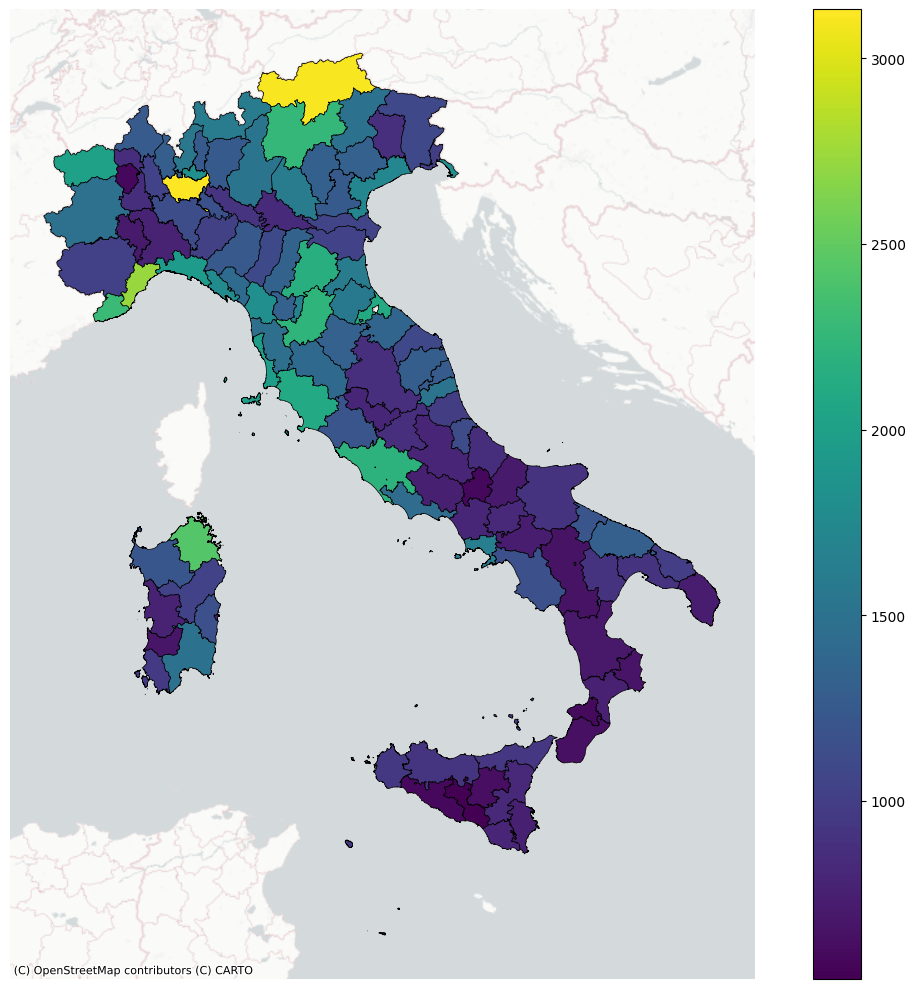

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="prov_buy_avg_wgt",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

Map - tourism indices

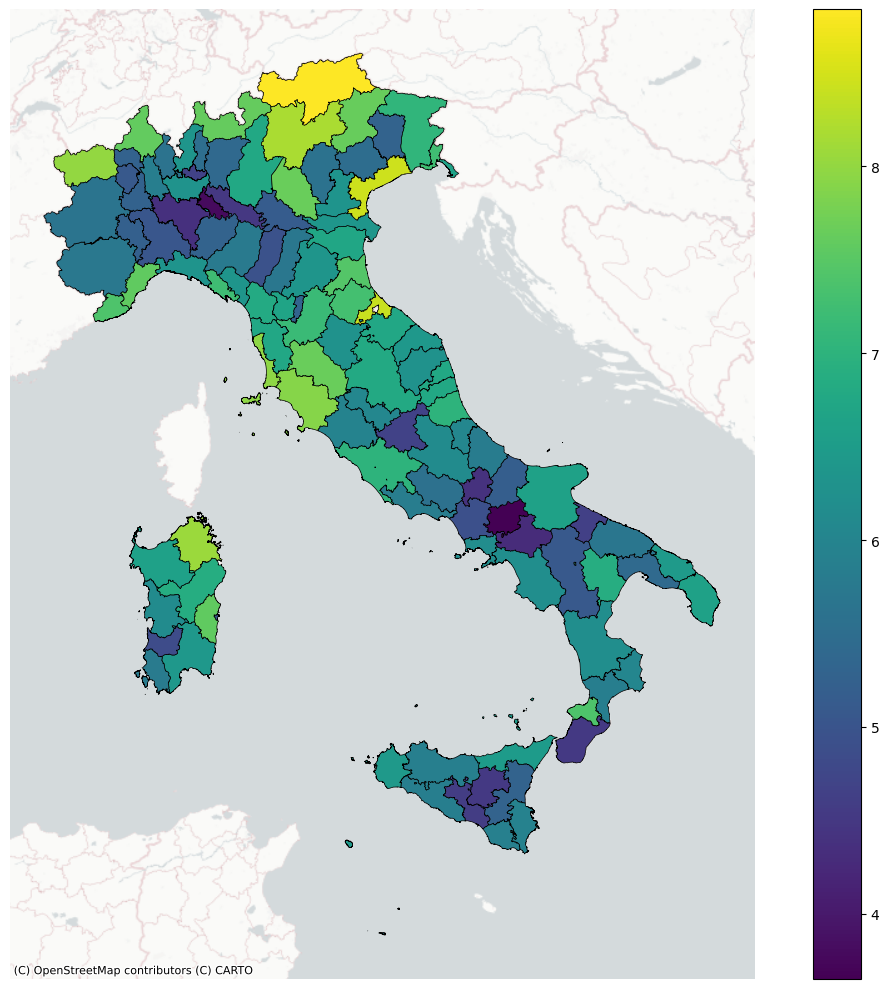

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="log_prov_ratio_tot_nights",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

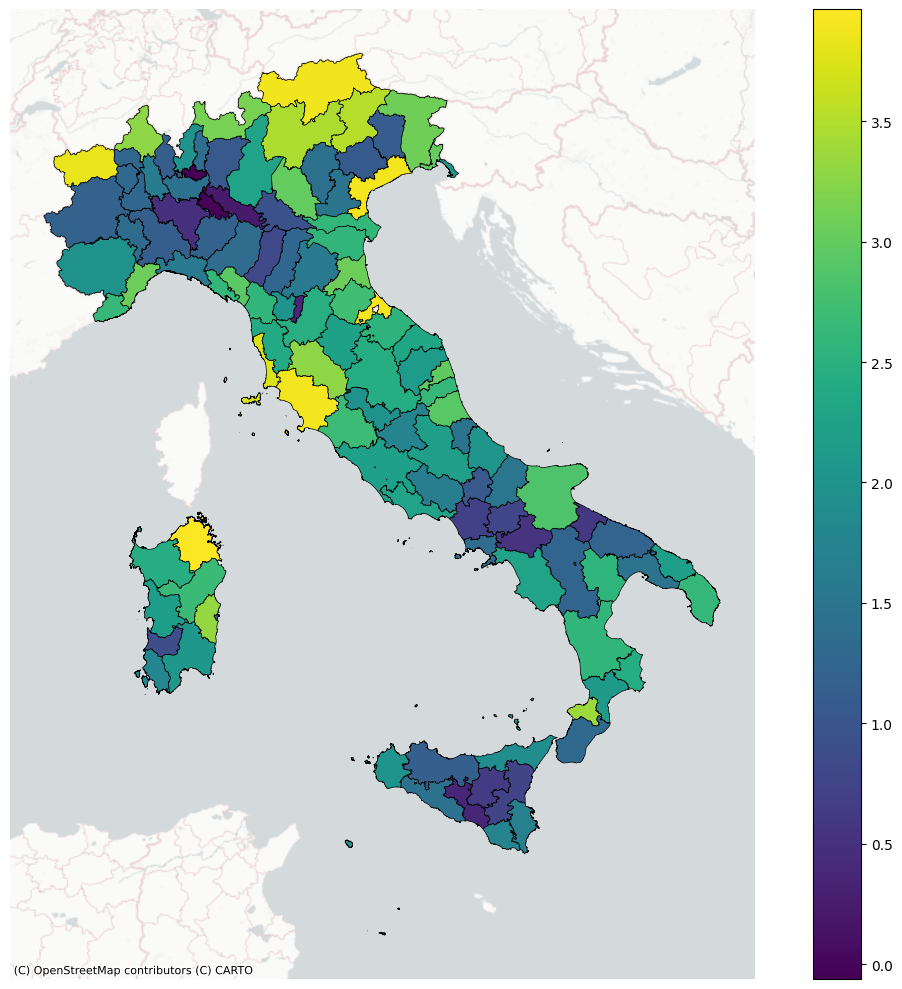

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="log_prov_ratio_tot_beds",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

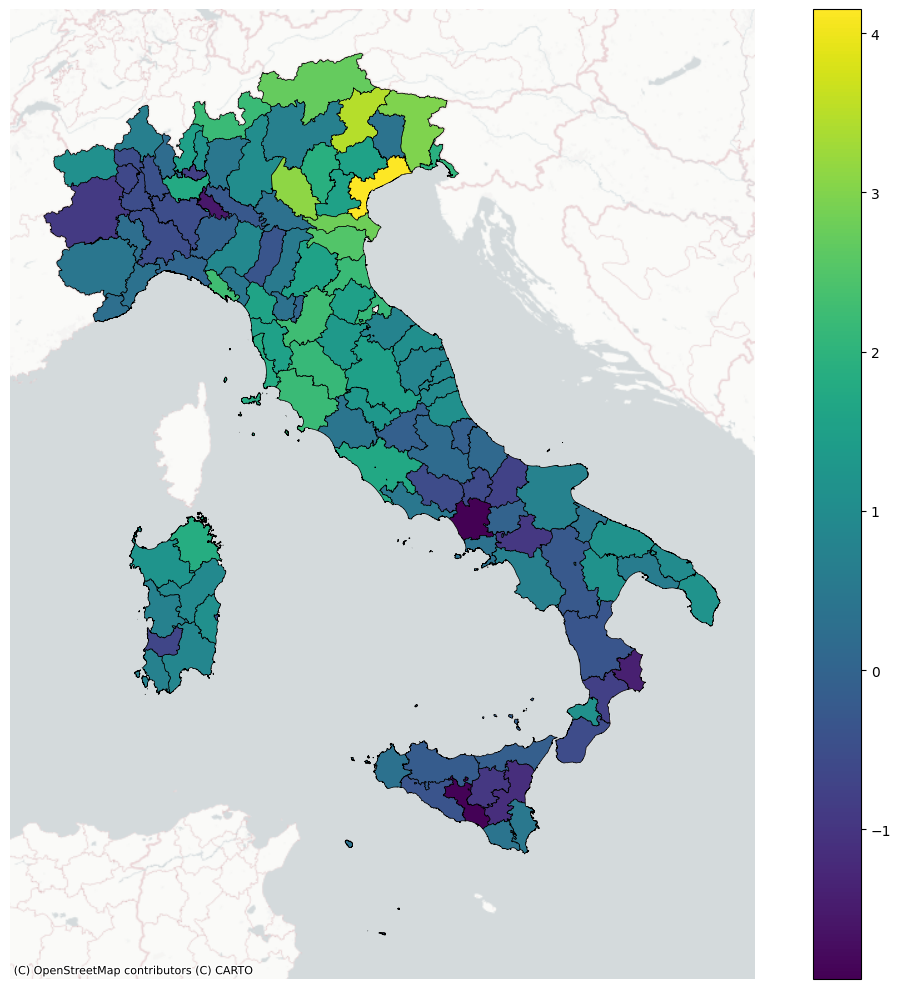

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="log_prov_ratio_str_houses",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

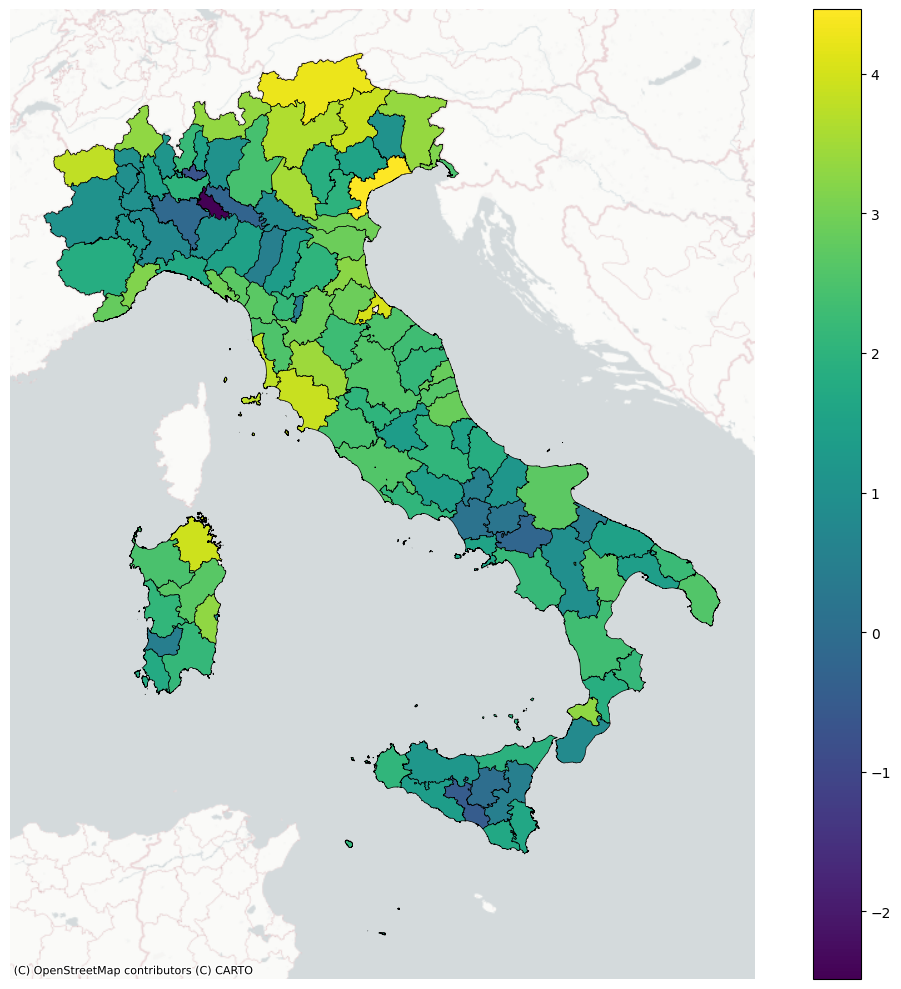

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

gdf = gdf_2024.to_crs(epsg=3857)

gdf.plot(
    column="log_tourism_index_z",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

cx.add_basemap(
    ax,
    source=cx.providers.CartoDB.PositronNoLabels
)

ax.set_axis_off()

plt.tight_layout()
plt.show()